In [62]:
from dotenv import load_dotenv
import os

load_dotenv()

from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")

In [63]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command

from IPython.display import Image, display

In [64]:
class State(TypedDict):
    query: str
    tool_result: str
    approved: bool

In [65]:
def tool_node(state: State):

    response = llm.invoke(
        f"Give a short answer about: {state['query']}"
    )

    return {
        "tool_result": response.content
    }

In [66]:
def human_node(state: State):

    decision = interrupt(
        {
            "message": "Do you approve this result?",
            "result": state["tool_result"]
        }
    )

    return {
        "approved": decision.lower() == "yes"
    }

In [67]:
def approval_router(state):
    if state["approved"]:
        return "approved"
    else:
        return "rejected"

In [68]:
def rejected_node(state):
    print("Request rejected by human.")
    return {}

In [69]:
builder = StateGraph(State)

builder.add_node("tool", tool_node)
builder.add_node("human", human_node)
builder.add_node("rejected", rejected_node)

builder.add_edge(START, "tool")
builder.add_edge("tool", "human")

builder.add_conditional_edges(
    "human",
    approval_router,
    {
        "approved": END,
        "rejected": "rejected"
    }
)

builder.add_edge("rejected", END)

In [70]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph = builder.compile(
    checkpointer=memory
)

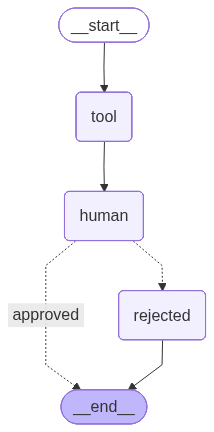

In [71]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [72]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

result = graph.invoke(
    {
        "query": "What is LangGraph?"
    },
    config=config
)

print(result)

{'query': 'What is LangGraph?', 'tool_result': 'LangGraph is a graph-based multilingual language model. It aims to integrate multiple languages and tasks into a unified framework, allowing for more efficient and effective knowledge transfer between languages.', '__interrupt__': [Interrupt(value={'message': 'Do you approve this result?', 'result': 'LangGraph is a graph-based multilingual language model. It aims to integrate multiple languages and tasks into a unified framework, allowing for more efficient and effective knowledge transfer between languages.'}, id='a85a2a7a6f2bac17518c65b567baa6a5')]}


In [73]:
approval = input("Approve? (yes/no): ")

In [74]:
final_result = graph.invoke(
    Command(resume=approval),
    config=config
)

print("\nFinal State:")
print(final_result)


Final State:
{'query': 'What is LangGraph?', 'tool_result': 'LangGraph is a graph-based multilingual language model. It aims to integrate multiple languages and tasks into a unified framework, allowing for more efficient and effective knowledge transfer between languages.', 'approved': True}


In [75]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

result = graph.invoke(
    {
        "query": "What is LangGraph?"
    },
    config=config
)

print(result)

{'query': 'What is LangGraph?', 'tool_result': 'I couldn\'t find any information on "LangGraph". However, I found that there is a LangGraph project on GitHub. It is an open-source, multilingual graph database, built on top of the JanusGraph database.', 'approved': True, '__interrupt__': [Interrupt(value={'message': 'Do you approve this result?', 'result': 'I couldn\'t find any information on "LangGraph". However, I found that there is a LangGraph project on GitHub. It is an open-source, multilingual graph database, built on top of the JanusGraph database.'}, id='137a05b4762fc30826a3704eb541d56e')]}


In [76]:
approval = input("Approve? (yes/no): ")

In [77]:
final_result = graph.invoke(
    Command(resume=approval),
    config=config
)

print("\nFinal State:")
print(final_result)

Request rejected by human.

Final State:
{'query': 'What is LangGraph?', 'tool_result': 'I couldn\'t find any information on "LangGraph". However, I found that there is a LangGraph project on GitHub. It is an open-source, multilingual graph database, built on top of the JanusGraph database.', 'approved': False}
